# Machine Learning-Based Stroke Prediction: Evaluating the Impact of Data Preprocessing Techniques

## 05_Models: Machine Learning Model Evaluation


## Introduction

### Research Objective

In this notebook, I train three models for stroke prediction: Logistic Regression, Random Forest, and XGBoost.

All models use the same stratified train/test split. I compare accuracy, precision, recall, and F1 score. Because stroke cases are rare, I pay more attention to recall and F1 than accuracy.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET_COLUMN = "stroke"

train_no_scaling = pd.read_csv(PROCESSED_DIR / "stroke_train_no_scaling.csv")
test_no_scaling = pd.read_csv(PROCESSED_DIR / "stroke_test_no_scaling.csv")
train_standard_scaled = pd.read_csv(PROCESSED_DIR / "stroke_train_standard_scaled.csv")
test_standard_scaled = pd.read_csv(PROCESSED_DIR / "stroke_test_standard_scaled.csv")

X_train_no_scaling = train_no_scaling.drop(columns=[TARGET_COLUMN])
X_test_no_scaling = test_no_scaling.drop(columns=[TARGET_COLUMN])
X_train_standard_scaled = train_standard_scaled.drop(columns=[TARGET_COLUMN])
X_test_standard_scaled = test_standard_scaled.drop(columns=[TARGET_COLUMN])
y_train = train_no_scaling[TARGET_COLUMN]
y_test = test_no_scaling[TARGET_COLUMN]

print(f"Training set shape: {X_train_no_scaling.shape}")
print(f"Test set shape: {X_test_no_scaling.shape}")
display(pd.DataFrame({
    "dataset": ["Training", "Test"],
    "rows": [len(y_train), len(y_test)],
    "stroke_cases": [int(y_train.sum()), int(y_test.sum())],
    "stroke_percentage": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)]
}))

Training set shape: (4088, 16)
Test set shape: (1022, 16)


,dataset,rows,stroke_cases,stroke_percentage
0,Training,4088,199,4.87
1,Test,1022,50,4.89


## Logistic Regression

I use Logistic Regression as a simple baseline. It is easy to understand and compare with the more complex models.

This model uses the scaled data. I also use class weights so the smaller stroke class has more influence during training.


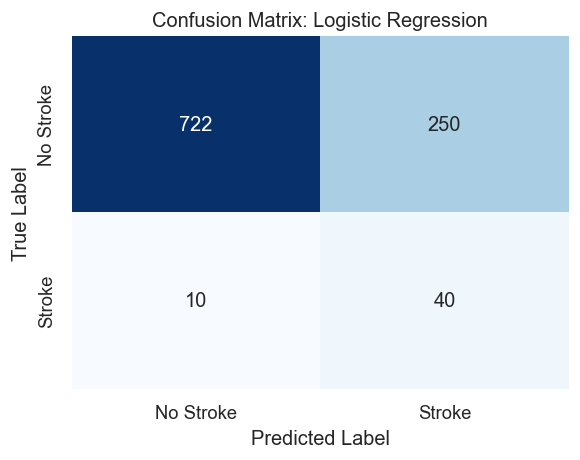

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.7456,0.1379,0.8,0.2353


In [2]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }

def save_confusion_matrix(y_true, y_pred, model_name, filename):
    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No Stroke", "Stroke"], yticklabels=["No Stroke", "Stroke"])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, bbox_inches="tight")
    plt.show()
    return matrix

logistic_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
logistic_model.fit(X_train_standard_scaled, y_train)
logistic_predictions = logistic_model.predict(X_test_standard_scaled)

logistic_metrics = evaluate_model("Logistic Regression", y_test, logistic_predictions)
logistic_confusion = save_confusion_matrix(
    y_test,
    logistic_predictions,
    "Logistic Regression",
    "confusion_matrix_logistic_regression.png"
)

display(pd.DataFrame([logistic_metrics]).round(4))

## Random Forest

Random Forest combines many decision trees and can learn non-linear patterns. It does not need scaled features, so I use the unscaled data.

I use class weights here as well to help with the class imbalance.


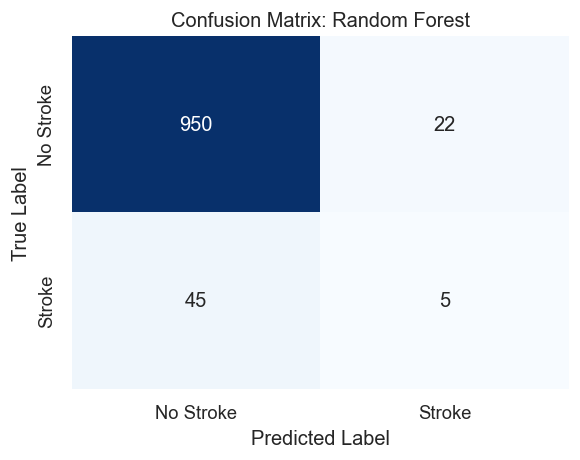

,model,accuracy,precision,recall,f1_score
0,Random Forest,0.9344,0.1852,0.1,0.1299


In [3]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)
random_forest_model.fit(X_train_no_scaling, y_train)
random_forest_predictions = random_forest_model.predict(X_test_no_scaling)

random_forest_metrics = evaluate_model("Random Forest", y_test, random_forest_predictions)
random_forest_confusion = save_confusion_matrix(
    y_test,
    random_forest_predictions,
    "Random Forest",
    "confusion_matrix_random_forest.png"
)

display(pd.DataFrame([random_forest_metrics]).round(4))

## XGBoost

XGBoost builds trees in steps, with each new tree trying to improve the earlier errors. It often works well with table-based data.

I use the unscaled data. To handle class imbalance, I set `scale_pos_weight` from the number of non-stroke and stroke cases in the training set.


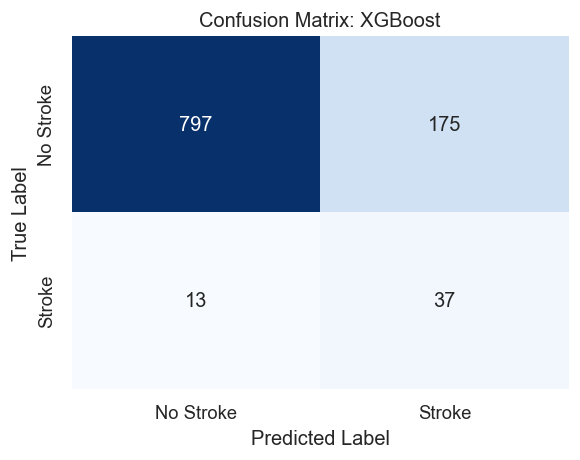

,model,accuracy,precision,recall,f1_score
0,XGBoost,0.816,0.1745,0.74,0.2824


In [4]:
negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()
scale_pos_weight = negative_cases / positive_cases

xgboost_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgboost_model.fit(X_train_no_scaling, y_train)
xgboost_predictions = xgboost_model.predict(X_test_no_scaling)

xgboost_metrics = evaluate_model("XGBoost", y_test, xgboost_predictions)
xgboost_confusion = save_confusion_matrix(
    y_test,
    xgboost_predictions,
    "XGBoost",
    "confusion_matrix_xgboost.png"
)

display(pd.DataFrame([xgboost_metrics]).round(4))

## Performance Comparison

I compare all three models using accuracy, precision, recall, and F1 score. Recall shows how many real stroke cases the model finds. F1 gives a balance between recall and precision.


,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.7456,0.1379,0.80,0.2353
1,Random Forest,0.9344,0.1852,0.10,0.1299
2,XGBoost,0.8160,0.1745,0.74,0.2824


,model,true_negative,false_positive,false_negative,true_positive
0,Logistic Regression,722,250,10,40
1,Random Forest,950,22,45,5
2,XGBoost,797,175,13,37


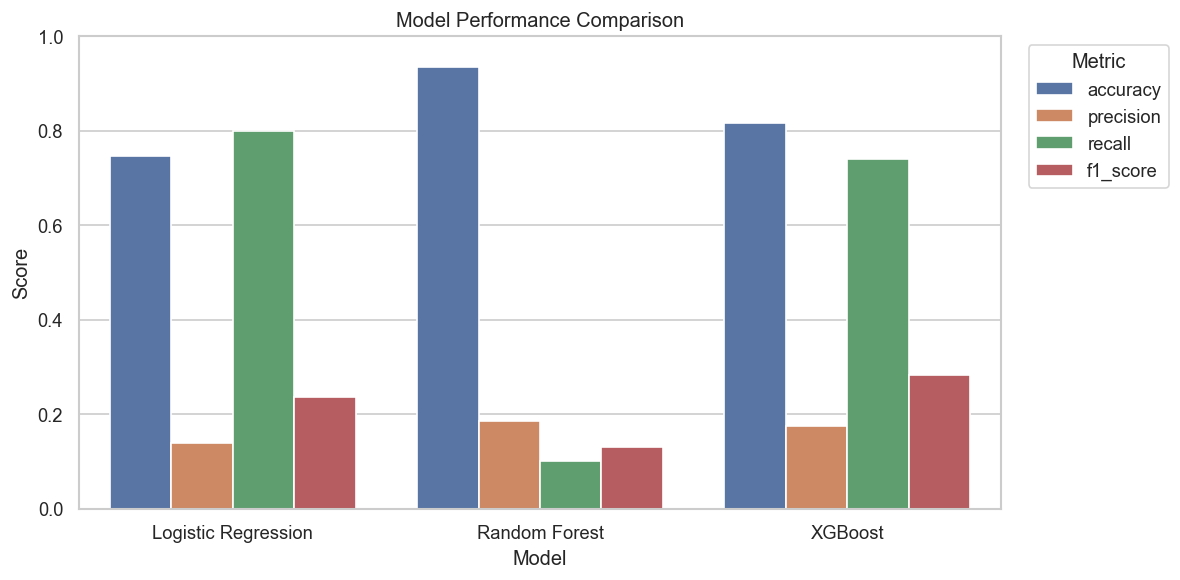

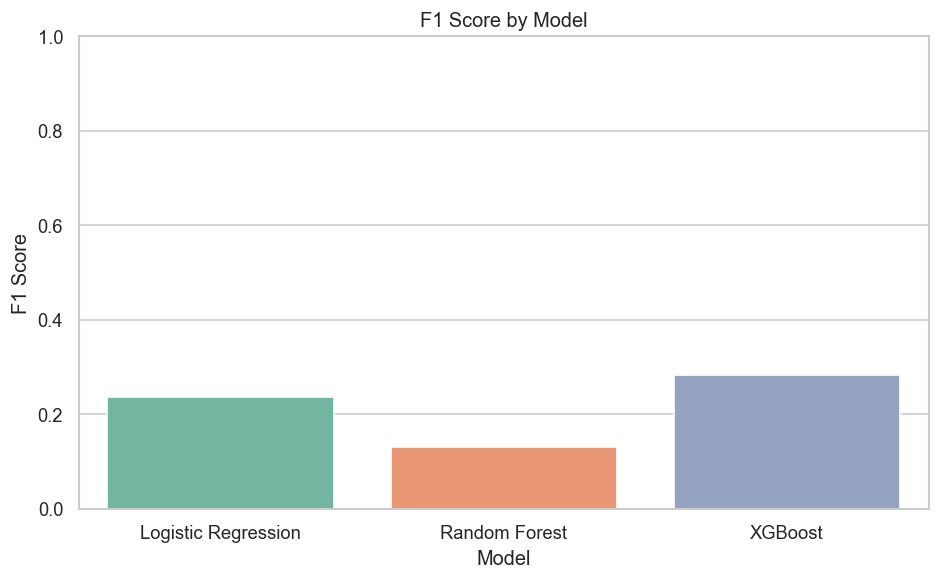

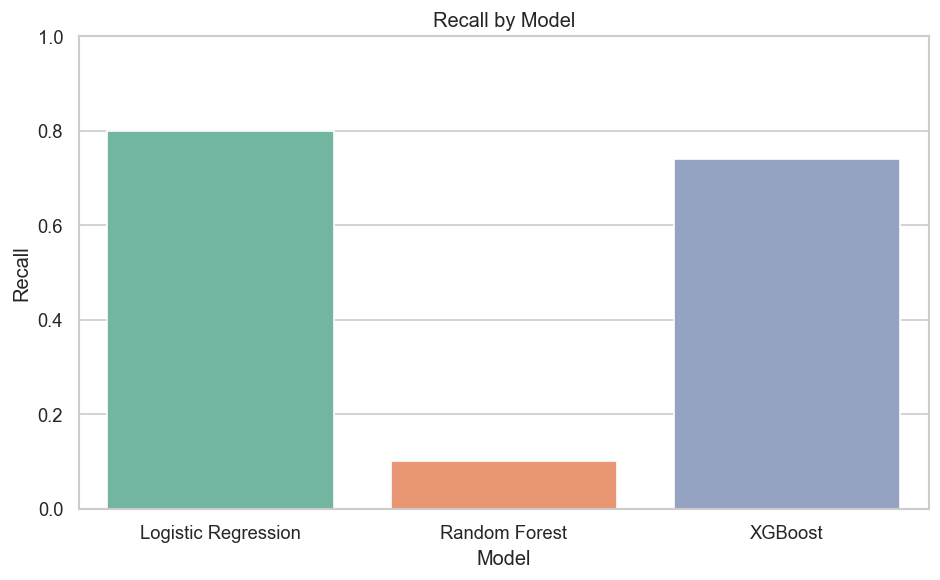

,criterion,model
0,Best model based on F1 Score,XGBoost
1,Best model based on Recall,Logistic Regression


In [5]:
performance_table = pd.DataFrame([
    logistic_metrics,
    random_forest_metrics,
    xgboost_metrics
]).round(4)

performance_table.to_csv(TABLES_DIR / "model_performance_comparison.csv", index=False)

confusion_rows = []
for model_name, matrix in [
    ("Logistic Regression", logistic_confusion),
    ("Random Forest", random_forest_confusion),
    ("XGBoost", xgboost_confusion)
]:
    tn, fp, fn, tp = matrix.ravel()
    confusion_rows.append({"model": model_name, "true_negative": tn, "false_positive": fp, "false_negative": fn, "true_positive": tp})

confusion_table = pd.DataFrame(confusion_rows)
confusion_table.to_csv(TABLES_DIR / "model_confusion_matrix_values.csv", index=False)

display(performance_table)
display(confusion_table)

metrics_long = performance_table.melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_long, x="model", y="score", hue="metric")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_performance_comparison_chart.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=performance_table, x="model", y="f1_score", hue="model", palette="Set2", legend=False)
plt.title("F1 Score by Model")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_f1_score_comparison.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=performance_table, x="model", y="recall", hue="model", palette="Set2", legend=False)
plt.title("Recall by Model")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_recall_comparison.png", bbox_inches="tight")
plt.show()

best_f1_model = performance_table.loc[performance_table["f1_score"].idxmax(), "model"]
best_recall_model = performance_table.loc[performance_table["recall"].idxmax(), "model"]

best_model_summary = pd.DataFrame({
    "criterion": ["Best model based on F1 Score", "Best model based on Recall"],
    "model": [best_f1_model, best_recall_model]
})
best_model_summary.to_csv(TABLES_DIR / "best_model_summary.csv", index=False)
display(best_model_summary)

## Discussion

Logistic Regression gives a clear baseline. Random Forest and XGBoost can learn more complex patterns and feature interactions.

Accuracy can look high even when a model misses many stroke cases, so I focus more on recall and F1. The confusion matrices also show the false negatives and false positives directly.

False negatives are especially important here because they are stroke cases that the model misses. False positives still matter, since too many false warnings would make a model less useful.


## Conclusion

I trained Logistic Regression, Random Forest, and XGBoost on the same train/test split. I compared them using accuracy, precision, recall, and F1 score, and saved the tables and figures.

These results give an early model comparison. A stronger final study would also use cross-validation, parameter tuning, threshold tuning, ROC-AUC, and PR-AUC.
